In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../datasets/500stock.csv")
df

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


In [8]:
df['Name'].nunique()

505

In [35]:
df.shape

(619040, 7)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


In [37]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


In [38]:
df['Name'] = df['Name'].astype('category').cat.codes
df

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,1
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,1
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,1
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,1
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,1
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,504
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,504
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,504
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,504


In [39]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df

,date,open,high,low,close,volume,Name,year,month,day
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,1,2013,2,8
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,1,2013,2,11
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,1,2013,2,12
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,1,2013,2,13
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,1,2013,2,14
...,...,...,...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,504,2018,2,1
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,504,2018,2,2
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,504,2018,2,5
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,504,2018,2,6


In [40]:
n_lags = 10


for lag in range(1, n_lags + 1):
    df[f'lag_{lag}'] = df['close'].shift(lag)

df['target_close'] = df['close'].shift(-1)
df.dropna().reset_index(drop=True, inplace = True)
df

,date,open,high,low,close,volume,Name,year,month,day,...,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,target_close
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,1,2013,2,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.46
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,1,2013,2,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.27
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,1,2013,2,12,...,14.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.66
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,1,2013,2,13,...,14.46,14.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.99
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,1,2013,2,14,...,14.27,14.46,14.75,NaN,NaN,NaN,NaN,NaN,NaN,14.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,504,2018,2,1,...,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,76.33,76.78
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,504,2018,2,2,...,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,73.83
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,504,2018,2,5,...,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,73.27
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,504,2018,2,6,...,76.78,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,73.86


In [41]:
df.drop('date', axis = 1, inplace = True)
df

,open,high,low,close,volume,Name,year,month,day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,target_close
0,15.07,15.12,14.63,14.75,8407500,1,2013,2,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.46
1,14.89,15.01,14.26,14.46,8882000,1,2013,2,11,14.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.27
2,14.45,14.51,14.10,14.27,8126000,1,2013,2,12,14.46,14.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.66
3,14.30,14.94,14.25,14.66,10259500,1,2013,2,13,14.27,14.46,14.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.99
4,14.94,14.96,13.16,13.99,31879900,1,2013,2,14,14.66,14.27,14.46,14.75,NaN,NaN,NaN,NaN,NaN,NaN,14.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619035,76.84,78.27,76.69,77.82,2982259,504,2018,2,1,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,76.33,76.78
619036,77.53,78.12,76.73,76.78,2595187,504,2018,2,2,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,73.83
619037,76.64,76.92,73.18,73.83,2962031,504,2018,2,5,76.78,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,73.27
619038,72.74,74.56,72.13,73.27,4924323,504,2018,2,6,73.83,76.78,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,73.86


In [42]:
df.dropna(inplace = True)
df

,open,high,low,close,volume,Name,year,month,day,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,target_close
10,13.60,13.76,13.00,13.02,7186400,1,2013,2,25,13.57,13.37,13.33,14.26,14.50,13.99,14.66,14.27,14.46,14.75,13.26
11,13.14,13.42,12.70,13.26,9419000,1,2013,2,26,13.02,13.57,13.37,13.33,14.26,14.50,13.99,14.66,14.27,14.46,13.41
12,13.28,13.62,13.18,13.41,7390500,1,2013,2,27,13.26,13.02,13.57,13.37,13.33,14.26,14.50,13.99,14.66,14.27,13.43
13,13.49,13.63,13.39,13.43,6143600,1,2013,2,28,13.41,13.26,13.02,13.57,13.37,13.33,14.26,14.50,13.99,14.66,13.61
14,13.37,13.95,13.32,13.61,7376800,1,2013,3,1,13.43,13.41,13.26,13.02,13.57,13.37,13.33,14.26,14.50,13.99,13.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619034,78.49,78.77,76.54,76.73,4136360,504,2018,1,31,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,76.33,76.77,77.82
619035,76.84,78.27,76.69,77.82,2982259,504,2018,2,1,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,76.33,76.78
619036,77.53,78.12,76.73,76.78,2595187,504,2018,2,2,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,76.62,73.83
619037,76.64,76.92,73.18,73.83,2962031,504,2018,2,5,76.78,77.82,76.73,78.35,79.18,80.09,79.25,78.33,77.59,77.48,73.27


In [43]:
from sklearn.model_selection import train_test_split

X =  df.drop('target_close', axis = 1)
y = df['target_close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(495214, 19) (495214,)
(123804, 19) (123804,)


--------------------------------------------
MODEL: LinearRegression()
The accuracy in validation set it's: R2: 99.76%, mae:0.955
The accuracy of in test set it's: R2: 99.67%, mae:0.842


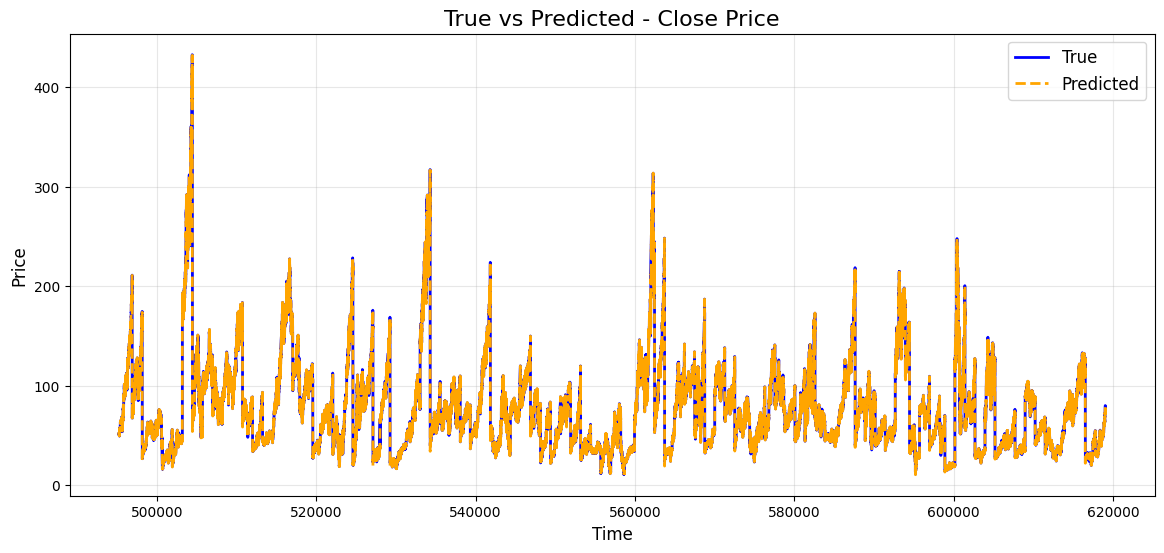

--------------------------------------------
MODEL: DecisionTreeRegressor()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
import numpy as np


models = [LinearRegression(), DecisionTreeRegressor()]

for model in models:
        print('--------------------------------------------')
        print(f"MODEL: {model}")

        pipe = Pipeline(
                steps=[
                ('Scaler', StandardScaler()),
                ("Model", model)
                ]
        )
        # TRAIN THE MODEL
        pipe.fit(X_train, y_train)

        # SEE THE ACCURACY OF THE TRAIN
        y_preds_train = pipe.predict(X_train)
        r2 = r2_score(y_train, y_preds_train)
        mae = mean_absolute_error(y_train, y_preds_train)
        print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")


        # SEE THE ACCURACY OF THE TEST
        y_preds_test = pipe.predict(X_test)
        r2 = r2_score(y_test, y_preds_test)
        mae = mean_absolute_error(y_test, y_preds_test)
        print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")

        plt.figure(figsize=(14,6))
        plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
        plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
        plt.title("True vs Predicted - Close Price", fontsize=16)
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Price", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=12)
        plt.show()

        

Model: Polynomial Regression, degree: 2
The accuracy in validation set it's: R2: 99.79%, mae:1.098
The accuracy of in test set it's: R2: 99.69%, mae:0.955


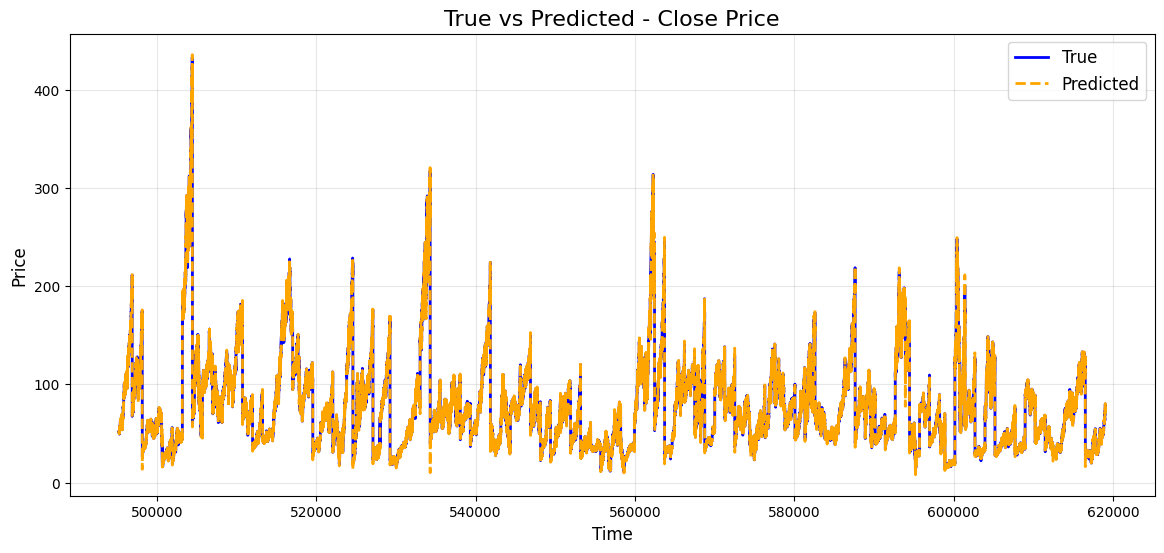

In [ ]:
degrees = 3

for degree in range(2, degrees):
    pipe = Pipeline(
    steps=[
        ("Scaler", StandardScaler()),
        ("Polynominal", PolynomialFeatures(degree = degree)),
        ("Model", LinearRegression())
    ])
    pipe.fit(X_train, y_train)

    # SEE THE ACCURACY OF THE TRAIN
    print(f"Model: Polynomial Regression, degree: {degree}")
    y_preds_train = pipe.predict(X_train)
    r2 = r2_score(y_train, y_preds_train)
    mae = mean_absolute_error(y_train, y_preds_train)
    print(F"The accuracy in validation set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")


    # SEE THE ACCURACY OF THE TEST
    y_preds_test = pipe.predict(X_test)
    r2 = r2_score(y_test, y_preds_test)
    mae = mean_absolute_error(y_test, y_preds_test)
    print(F"The accuracy of in test set it's: R2: {r2*100:.2f}%, mae:{mae:.3f}")

    plt.figure(figsize=(14,6))
    plt.plot(y_test.index, y_test.values, label='True', color='blue', linewidth=2)
    plt.plot(y_test.index, y_preds_test, label='Predicted', color='orange', linestyle='--', linewidth=2)
    plt.title("True vs Predicted - Close Price", fontsize=16)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Price", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.show()
    